# AI Resume Analyzer with ATS Scoring and Job Matching
### Team Members: [Khushi, Kashish, Bhavya, Diya]
### Project Roadmap:
1. Resume Upload & Text Extraction
2. Text Preprocessing
3. Feature Extraction (TF-IDF)
4. Similarity Matching (Cosine Similarity)
5. ATS Scoring
6. Job Matching
7. Evaluation
8. Streamlit Interface

Setup & Dataset Download from Kaggle

In [ ]:
import os
import pandas as pd

try:
    import kagglehub
    path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
    print("Path to downloaded dataset files:", path)

    csv_file = None
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_file = os.path.join(root, file)
                break
        if csv_file:
            break

    if csv_file and os.path.exists(csv_file):
        print(f"Found dataset CSV at: {csv_file}")
        df_raw = pd.read_csv(csv_file)
        print("Dataset loaded successfully from Kaggle via kagglehub!")
    else:
        raise FileNotFoundError("No CSV file found in downloaded kagglehub folder.")


except Exception as e:
    print(f"Kaggle download note: {e}")

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to downloaded dataset files: /kaggle/input/resume-dataset
Found dataset CSV at: /kaggle/input/resume-dataset/Resume/Resume.csv
Dataset loaded successfully from Kaggle via kagglehub!


Import Required Libraries

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             silhouette_score)

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All libraries imported successfully!


Dataset Loading & Inspection

In [ ]:
print("Dataset Shape:", df_raw.shape)
print("\nDataset Columns:", df_raw.columns.tolist())
print("\nFirst 3 rows:")
display(df_raw.head(3))



Dataset Shape: (2484, 4)

Dataset Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

First 3 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


Exploratory Data Analysis

/tmp/ipykernel_546/1084798620.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


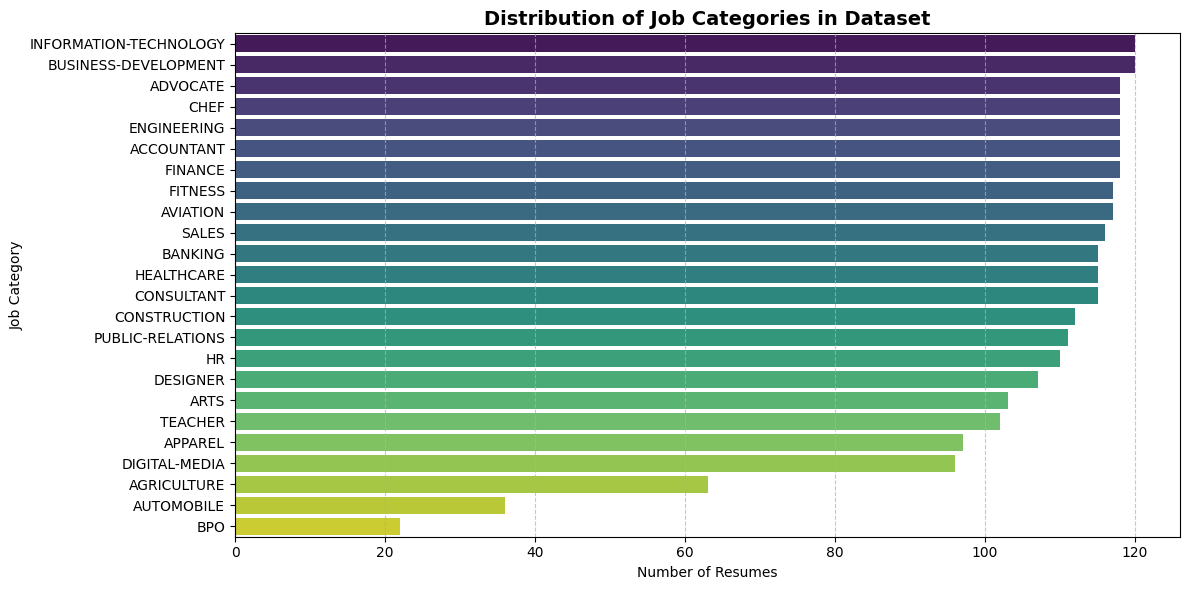


Total Unique Categories: 24
Category Distribution:
 Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(12, 6))
category_counts = df_raw['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title("Distribution of Job Categories in Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Number of Resumes")
plt.ylabel("Job Category")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTotal Unique Categories:", df_raw['Category'].nunique())
print("Category Distribution:\n", category_counts)

Data Cleaning & Missing Value Check

In [ ]:
print("Missing values per column before cleaning:")
print(df_raw.isnull().sum())

df = df_raw[['ID', 'Resume_str', 'Category']].copy()

df.dropna(subset=['Resume_str', 'Category'], inplace=True)

initial_len = len(df)
df.drop_duplicates(subset=['Resume_str'], inplace=True)
print(f"\nRemoved {initial_len - len(df)} duplicate resumes. Remaining rows: {len(df)}")

Missing values per column before cleaning:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Removed 2 duplicate resumes. Remaining rows: 2482


NLP Text Preprocessing Pipeline

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|<.*?>|\S+@\S+', ' ', text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    cleaned_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    return " ".join(cleaned_tokens)

print("Preprocessing resume text... Please wait.")
df['cleaned_resume'] = df['Resume_str'].apply(clean_text)
print("Text preprocessing completed successfully!")

print("\n--- SAMPLE BEFORE PREPROCESSING ---")
print(df['Resume_str'].iloc[0][:200])
print("\n--- SAMPLE AFTER PREPROCESSING ---")
print(df['cleaned_resume'].iloc[0][:200])

Preprocessing resume text... Please wait.
Text preprocessing completed successfully!

--- SAMPLE BEFORE PREPROCESSING ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

--- SAMPLE AFTER PREPROCESSING ---
administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri


Defining Target Job Descriptions & Skill Taxonomies

In [ ]:
JOB_DESCRIPTIONS = {
    "Data Science": """
    Seeking a Data Scientist proficient in Python, SQL, Machine Learning, Scikit-Learn,
    Pandas, NumPy, Data Analysis, Statistics, Feature Engineering, Matplotlib,
    Seaborn, K-Means Clustering, Classification, and Predictive Modeling.
    Experience in big data, data visualization, and model evaluation required.
    """,

    "Software Development": """
    Looking for a Software Engineer with expertise in Java, Python, Data Structures,
    Algorithms, Git, Object Oriented Programming, Software Architecture, SQL,
    Unit Testing, Debugging, REST APIs, System Design, and Agile methodology.
    """,

    "Human Resources": """
    HR Manager responsible for Talent Acquisition, Candidate Screening, Recruitment,
    Employee Engagement, HR Policies, Payroll, Performance Management, Onboarding,
    Interviews, Labor Laws, and Organizational Development.
    """,

    "Business Analyst": """
    Business Analyst required with skills in Requirement Gathering, Process Modeling,
    SQL, Tableau, Power BI, Excel, Business Intelligence, Data Analysis,
    Agile, Scrum, User Stories, and Stakeholder Management.
    """
}

CLEANED_JOBS = {role: clean_text(text) for role, text in JOB_DESCRIPTIONS.items()}
SKILL_DICTIONARY = [
    'python', 'java', 'c++', 'sql', 'mysql', 'postgresql', 'machine learning',
    'data analysis', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn',
    'statistics', 'k-means', 'regression', 'classification', 'data structures',
    'algorithms', 'git', 'tableau', 'power bi', 'excel', 'agile', 'scrum',
    'talent acquisition', 'recruitment', 'payroll', 'system design', 'rest api'
]

def extract_skills(text, skill_set=SKILL_DICTIONARY):
    """Extracts matching skills present in the text."""
    found_skills = set()
    for skill in skill_set:
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text):
            found_skills.add(skill)
    return found_skills

print("Job descriptions and skill taxonomies defined successfully!")

Job descriptions and skill taxonomies defined successfully!


TF-IDF Feature Extraction

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_resume'])

print("TF-IDF Matrix Shape (Resumes x Features):", tfidf_matrix.shape)
print("Sample Extracted Vocabulary:", tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF Matrix Shape (Resumes x Features): (2482, 1500)
Sample Extracted Vocabulary: ['abilities' 'ability' 'able' 'academic' 'access' 'accomplished'
 'accomplishments' 'accordance' 'according' 'account' 'account management'
 'accountant' 'accounting' 'accounts' 'accounts payable'
 'accounts receivable' 'accuracy' 'accurate' 'accurately' 'achieve']


Cosine Similarity Functions

In [ ]:
def calculate_similarity(resume_text, job_text, vectorizer):
    """Computes Cosine Similarity between a resume and a job description."""
    vectors = vectorizer.transform([resume_text, job_text])
    sim = cosine_similarity(vectors[0], vectors[1])[0][0]
    return float(sim)
demo_resume = df['cleaned_resume'].iloc[0]
demo_job = CLEANED_JOBS['Data Science']
demo_sim = calculate_similarity(demo_resume, demo_job, tfidf_vectorizer)

print(f"Candidate Resume Category: {df['Category'].iloc[0]}")
print(f"Cosine Similarity with 'Data Science' Job Description: {demo_sim:.4f} ({demo_sim*100:.2f}%)")

Candidate Resume Category: HR
Cosine Similarity with 'Data Science' Job Description: 0.0949 (9.49%)


ATS Compatibility Score Computation

In [ ]:
def calculate_ats_score(resume_text, job_text, vectorizer):
    """
    Calculates a transparent ATS Compatibility Score (0 - 100%).
    Formula:
    ATS Score = (0.50 * Cosine Similarity) +
                (0.35 * Skill Overlap Percentage) +
                (0.15 * Keyword Overlap Ratio)
    """
    cos_sim = calculate_similarity(resume_text, job_text, vectorizer)

    res_skills = extract_skills(resume_text)
    job_skills = extract_skills(job_text)

    if len(job_skills) > 0:
        matched_skills = res_skills.intersection(job_skills)
        skill_score = len(matched_skills) / len(job_skills)
    else:
        skill_score = cos_sim
        matched_skills = set()

    res_words = set(resume_text.split())
    job_words = set(job_text.split())

    if len(job_words) > 0:
        keyword_overlap = len(res_words.intersection(job_words)) / len(job_words)
    else:
        keyword_overlap = 0.0

    ats_score = (0.50 * cos_sim) + (0.35 * skill_score) + (0.15 * keyword_overlap)
    ats_score_pct = round(ats_score * 100, 2)

    return {
        "ats_score": ats_score_pct,
        "cosine_sim": round(cos_sim * 100, 2),
        "skill_match_pct": round(skill_score * 100, 2),
        "matched_skills": list(matched_skills),
        "missing_skills": list(job_skills - res_skills)
    }

sample_result = calculate_ats_score(demo_resume, demo_job, tfidf_vectorizer)
print("--- DEMO ATS SCORE REPORT ---")
print(f"Overall ATS Score: {sample_result['ats_score']}%")
print(f"Cosine Similarity: {sample_result['cosine_sim']}%")
print(f"Skill Match %: {sample_result['skill_match_pct']}%")
print(f"Matched Skills: {sample_result['matched_skills']}")
print(f"Missing Skills: {sample_result['missing_skills']}")

--- DEMO ATS SCORE REPORT ---
Overall ATS Score: 14.33%
Cosine Similarity: 9.49%
Skill Match %: 20.0%
Matched Skills: ['data analysis', 'statistics']
Missing Skills: ['python', 'classification', 'sql', 'pandas', 'seaborn', 'numpy', 'machine learning', 'matplotlib']


Stratified Train-Test Dataset Splitting

In [ ]:
X = tfidf_matrix
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("===== DATASET SPLIT =====")
print(f"Total samples: {X.shape[0]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

===== DATASET SPLIT =====
Total samples: 2482
Training samples: 1985
Testing samples: 497

Training feature shape: (1985, 1500)
Testing feature shape: (497, 1500)

Training class distribution:
Category
INFORMATION-TECHNOLOGY    96
BUSINESS-DEVELOPMENT      96
ACCOUNTANT                94
CHEF                      94
ENGINEERING               94
ADVOCATE                  94
FITNESS                   93
FINANCE                   93
SALES                     93
AVIATION                  93
BANKING                   92
HEALTHCARE                92
CONSULTANT                92
CONSTRUCTION              90
PUBLIC-RELATIONS          89
HR                        88
DESIGNER                  86
TEACHER                   82
ARTS                      82
APPAREL                   78
DIGITAL-MEDIA             77
AGRICULTURE               50
AUTOMOBILE                29
BPO                       18
Name: count, dtype: int64

Testing class distribution:
Category
FINANCE                   24
BUSINESS-

Supervised Model Training

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    results[name] = {
        "model": model,
        "predictions": y_pred,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }
df_results = pd.DataFrame(results).T[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score']
]
print("\n" + "="*70)
print("       SUPERVISED MODEL PERFORMANCE COMPARISON")
print("="*70)

display(df_results)

print("\nPerformance in Percentage:")
display((df_results * 100).round(2))


Training Logistic Regression...

Training Random Forest...

Training K-Nearest Neighbors...

       SUPERVISED MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.65996,0.660636,0.65996,0.642147
Random Forest,0.692153,0.701565,0.692153,0.669741
K-Nearest Neighbors,0.547284,0.583958,0.547284,0.541696



Performance in Percentage:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,65.995976,66.063581,65.995976,64.214688
Random Forest,69.215292,70.156529,69.215292,66.974099
K-Nearest Neighbors,54.72837,58.395833,54.72837,54.169641


5-Fold Stratified Cross-Validation

In [ ]:
print("="*70)
print("          5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*70)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )
    cv_results[name] = scores

    print(f"\n{name}")
    print("-" * 50)

    for i, score in enumerate(scores, start=1):
        print(f"Fold {i} Accuracy: {score * 100:.2f}%")

    print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
    print(f"Standard Deviation: ±{scores.std() * 100:.2f}%")

          5-FOLD STRATIFIED CROSS-VALIDATION

Logistic Regression
--------------------------------------------------
Fold 1 Accuracy: 66.60%
Fold 2 Accuracy: 66.00%
Fold 3 Accuracy: 66.73%
Fold 4 Accuracy: 68.55%
Fold 5 Accuracy: 65.73%
Mean Accuracy: 66.72%
Standard Deviation: ±0.99%

Random Forest
--------------------------------------------------
Fold 1 Accuracy: 70.42%
Fold 2 Accuracy: 69.82%
Fold 3 Accuracy: 67.94%
Fold 4 Accuracy: 71.77%
Fold 5 Accuracy: 69.96%
Mean Accuracy: 69.98%
Standard Deviation: ±1.23%

K-Nearest Neighbors
--------------------------------------------------
Fold 1 Accuracy: 52.11%
Fold 2 Accuracy: 54.53%
Fold 3 Accuracy: 55.44%
Fold 4 Accuracy: 56.45%
Fold 5 Accuracy: 52.02%
Mean Accuracy: 54.11%
Standard Deviation: ±1.78%


Model Visualizations & Confusion Matrix

                  BEST MODEL
Best Model: Random Forest
Best F1-Score: 66.97%


<Figure size 1000x600 with 0 Axes>

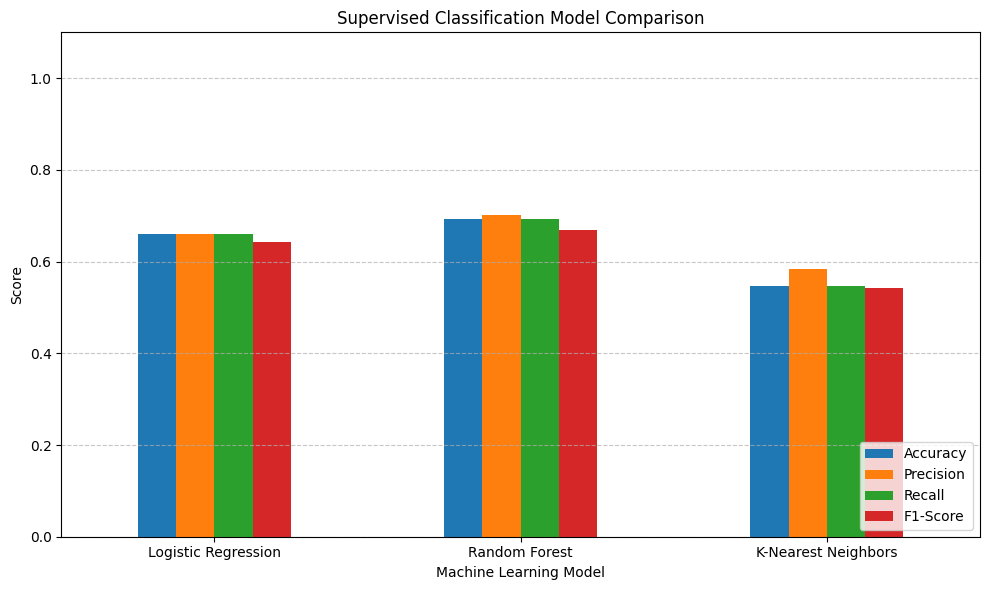

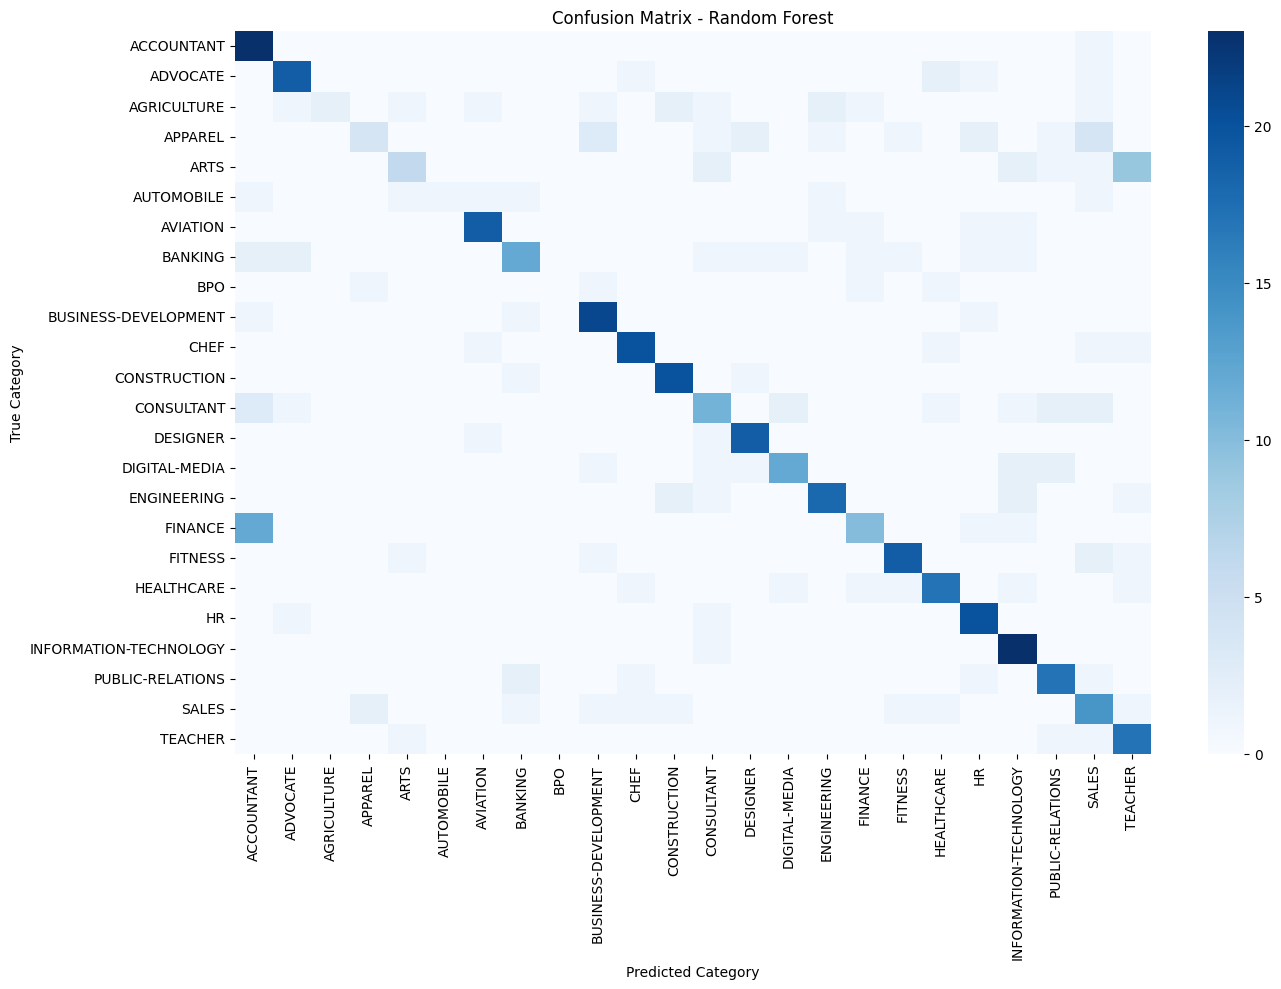

       CLASSIFICATION REPORT - Random Forest
                        precision    recall  f1-score   support

            ACCOUNTANT       0.55      0.96      0.70        24
              ADVOCATE       0.79      0.79      0.79        24
           AGRICULTURE       1.00      0.15      0.27        13
               APPAREL       0.57      0.21      0.31        19
                  ARTS       0.60      0.29      0.39        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.83      0.83      0.83        23
               BANKING       0.67      0.52      0.59        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.72      0.88      0.79        24
                  CHEF       0.83      0.83      0.83        24
          CONSTRUCTION       0.80      0.91      0.85        22
            CONSULTANT       0.52      0.48      0.50        23
              DESIGNER       0.79      0.90      0.84     

In [ ]:
best_model_name = df_results['F1-Score'].astype(float).idxmax()

print("="*70)
print("                  BEST MODEL")
print("="*70)

print("Best Model:", best_model_name)
print(
    f"Best F1-Score: "
    f"{df_results.loc[best_model_name, 'F1-Score'] * 100:.2f}%"
)

plt.figure(figsize=(10, 6))

df_results.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Supervised Classification Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()


best_pred = results[best_model_name]['predictions']

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=models[best_model_name].classes_
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    fmt='d',
    xticklabels=models[best_model_name].classes_,
    yticklabels=models[best_model_name].classes_
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Category")
plt.ylabel("True Category")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


print("="*70)
print(f"       CLASSIFICATION REPORT - {best_model_name}")
print("="*70)

print(
    classification_report(
        y_test,
        best_pred,
        zero_division=0
    )
)

 K-Means Clustering & 2D PCA Plot

K-Means (K=5) Silhouette Score: 0.0335


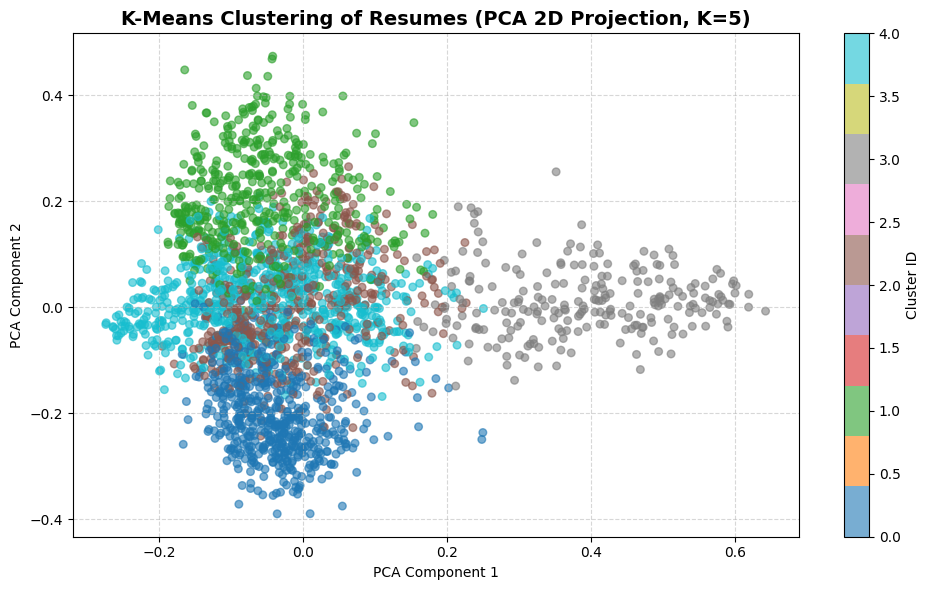

In [ ]:
k_clusters = 5
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tfidf_matrix)

sil_score = silhouette_score(tfidf_matrix, cluster_labels)
print(f"K-Means (K={k_clusters}) Silhouette Score: {sil_score:.4f}")

pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 6))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=30)
plt.title(f"K-Means Clustering of Resumes (PCA 2D Projection, K={k_clusters})", fontsize=14, fontweight='bold')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Job Recommendation System Engine

In [ ]:
def recommend_jobs_for_resume(resume_text, job_dict, vectorizer, top_n=3):
    scores = []
    for role, job_text in job_dict.items():
        sim = calculate_similarity(resume_text, job_text, vectorizer)
        ats = calculate_ats_score(resume_text, job_text, vectorizer)['ats_score']
        scores.append({
            "Job Role": role,
            "Cosine Similarity": round(sim, 4),
            "Similarity %": f"{round(sim*100, 2)}%",
            "ATS Compatibility Score": f"{ats}%"
        })
    df_rec = pd.DataFrame(scores).sort_values(by="Cosine Similarity", ascending=False)
    return df_rec.head(top_n)

test_resume_idx = 10
sample_res_text = df['cleaned_resume'].iloc[test_resume_idx]
sample_actual_cat = df['Category'].iloc[test_resume_idx]

print(f"--- CANDIDATE RESUME TEST (True Role: {sample_actual_cat}) ---")
df_recommendations = recommend_jobs_for_resume(sample_res_text, CLEANED_JOBS, tfidf_vectorizer)
display(df_recommendations)

--- CANDIDATE RESUME TEST (True Role: HR) ---


,Job Role,Cosine Similarity,Similarity %,ATS Compatibility Score
2,Human Resources,0.1235,12.35%,38.19%
3,Business Analyst,0.0311,3.11%,4.41%
0,Data Science,0.0293,2.93%,3.01%


Skill Gap Analysis Module

In [ ]:
def analyze_skill_gap(resume_text, target_job_text):
    res_skills = extract_skills(resume_text)
    job_skills = extract_skills(target_job_text)

    matched = res_skills.intersection(job_skills)
    missing = job_skills - res_skills

    return {
        "Matched Skills Count": len(matched),
        "Matched Skills List": sorted(list(matched)),
        "Missing Skills Count": len(missing),
        "Missing Skills List": sorted(list(missing))
    }

gap_report = analyze_skill_gap(sample_res_text, CLEANED_JOBS['Data Science'])

print("--- CANDIDATE SKILL GAP ANALYSIS REPORT ---")
print(f"Target Role: Data Science")
print(f"Matched Skills ({gap_report['Matched Skills Count']}): {gap_report['Matched Skills List']}")
print(f"Missing Skills ({gap_report['Missing Skills Count']}): {gap_report['Missing Skills List']}")

--- CANDIDATE SKILL GAP ANALYSIS REPORT ---
Target Role: Data Science
Matched Skills (0): []
Missing Skills (10): ['classification', 'data analysis', 'machine learning', 'matplotlib', 'numpy', 'pandas', 'python', 'seaborn', 'sql', 'statistics']


Live Custom Testcase Demo

In [ ]:
sample_resume_text = """
Rahul Sharma
Data Science Intern & CSE Student
Email: rahul.sharma@example.com

PROFESSIONAL SUMMARY:
Enthusiastic Computer Science student with strong foundation in Machine Learning,
Data Analysis, and Python programming. Experienced in building predictive models
using Pandas, NumPy, Scikit-Learn, and Matplotlib. Proficient in SQL database querying.

TECHNICAL SKILLS:
- Languages: Python, SQL, C++
- Data Science Libraries: Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn
- ML Concepts: Regression, Classification, K-Means Clustering, Feature Engineering
- Tools: Git, Jupyter Notebook, VS Code
"""

target_job_description = """
We are looking for a Data Scientist to join our team.
Required Skills: Python, SQL, Machine Learning, Scikit-Learn, Pandas, NumPy,
Data Analysis, Statistics, Git, REST API, Tableau, and AWS cloud deployment.
"""

cleaned_custom_resume = clean_text(sample_resume_text)
cleaned_custom_job = clean_text(target_job_description)

print("="*60)
print("             LIVE DEMO: RESUME ANALYZER OUTPUT             ")
print("="*60)

custom_vector = tfidf_vectorizer.transform([cleaned_custom_resume])
predicted_category = models["Logistic Regression"].predict(custom_vector)[0]
print(f"\n1. PREDICTED JOB CATEGORY: {predicted_category}")

ats_report = calculate_ats_score(cleaned_custom_resume, cleaned_custom_job, tfidf_vectorizer)
print(f"\n2. ATS COMPATIBILITY SCORE: {ats_report['ats_score']}%")
print(f"   - Cosine Similarity: {ats_report['cosine_sim']}%")
print(f"   - Skill Overlap Percentage: {ats_report['skill_match_pct']}%")

print(f"\n3. MATCHED SKILLS ({len(ats_report['matched_skills'])}): {ats_report['matched_skills']}")
print(f"\n4. MISSING SKILLS ({len(ats_report['missing_skills'])}): {ats_report['missing_skills']}")

print(f"\n5. TOP RECOMMENDED ROLES FOR THIS RESUME:")
rec_df = recommend_jobs_for_resume(cleaned_custom_resume, CLEANED_JOBS, tfidf_vectorizer, top_n=3)
display(rec_df)
print("="*60)

             LIVE DEMO: RESUME ANALYZER OUTPUT             

1. PREDICTED JOB CATEGORY: ENGINEERING

2. ATS COMPATIBILITY SCORE: 56.2%
   - Cosine Similarity: 48.4%
   - Skill Overlap Percentage: 70.0%

3. MATCHED SKILLS (7): ['python', 'sql', 'pandas', 'numpy', 'data analysis', 'git', 'machine learning']

4. MISSING SKILLS (3): ['tableau', 'rest api', 'statistics']

5. TOP RECOMMENDED ROLES FOR THIS RESUME:


,Job Role,Cosine Similarity,Similarity %,ATS Compatibility Score
0,Data Science,0.5137,51.37%,67.01%
3,Business Analyst,0.2586,25.86%,27.46%
1,Software Development,0.2303,23.03%,27.77%


Interactive Resume File Upload Module

In [ ]:
import io
from google.colab import files

print("Upload a Candidate Resume file (.txt or .pdf):")
uploaded = files.upload()

uploaded_resume_text = ""

for filename in uploaded.keys():
    print(f"\nProcessing uploaded file: {filename}")
    if filename.endswith('.txt'):
        uploaded_resume_text = uploaded[filename].decode("utf-8", errors="ignore")
    elif filename.endswith('.pdf'):
        try:
            import pypdf
        except ImportError:
            !pip install pypdf -q
            import pypdf

        reader = pypdf.PdfReader(io.BytesIO(uploaded[filename]))
        text_pages = [page.extract_text() for page in reader.pages if page.extract_text()]
        uploaded_resume_text = " ".join(text_pages)
    else:
        print("Unsupported file format. Please upload a .txt or .pdf file.")

if uploaded_resume_text.strip():
    cleaned_uploaded_resume = clean_text(uploaded_resume_text)

    target_role = "Data Science"
    target_job_text = CLEANED_JOBS[target_role]

    print("\n" + "="*60)
    print("      ANALYSIS REPORT FOR UPLOADED RESUME FILE      ")
    print("="*60)

    up_vector = tfidf_vectorizer.transform([cleaned_uploaded_resume])
    pred_cat = models["Logistic Regression"].predict(up_vector)[0]
    print(f"\n1. PREDICTED JOB CATEGORY: {pred_cat}")

    ats_up = calculate_ats_score(cleaned_uploaded_resume, target_job_text, tfidf_vectorizer)
    print(f"\n2. ATS COMPATIBILITY SCORE (vs {target_role}): {ats_up['ats_score']}%")
    print(f"   - Cosine Similarity: {ats_up['cosine_sim']}%")
    print(f"   - Skill Overlap %:   {ats_up['skill_match_pct']}%")

    print(f"\n3. MATCHED SKILLS ({len(ats_up['matched_skills'])}): {ats_up['matched_skills']}")
    print(f"\n4. MISSING SKILLS ({len(ats_up['missing_skills'])}): {ats_up['missing_skills']}")

    print(f"\n5. TOP RECOMMENDED ROLES:")
    up_recs = recommend_jobs_for_resume(cleaned_uploaded_resume, CLEANED_JOBS, tfidf_vectorizer, top_n=3)
    display(up_recs)
    print("="*60)
else:
    print("No readable text could be extracted from the uploaded file.")

Upload a Candidate Resume file (.txt or .pdf):


Saving sample resume.pdf to sample resume.pdf

Processing uploaded file: sample resume.pdf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 7.8 MB/s eta 0:00:00

      ANALYSIS REPORT FOR UPLOADED RESUME FILE      

1. PREDICTED JOB CATEGORY: INFORMATION-TECHNOLOGY

2. ATS COMPATIBILITY SCORE (vs Data Science): 38.54%
   - Cosine Similarity: 28.63%
   - Skill Overlap %:   50.0%

3. MATCHED SKILLS (5): ['python', 'sql', 'pandas', 'numpy', 'machine learning']

4. MISSING SKILLS (5): ['statistics', 'classification', 'seaborn', 'data analysis', 'matplotlib']

5. TOP RECOMMENDED ROLES:


,Job Role,Cosine Similarity,Similarity %,ATS Compatibility Score
0,Data Science,0.2863,28.63%,38.54%
1,Software Development,0.2199,21.99%,41.0%
3,Business Analyst,0.0761,7.61%,13.21%
